## Import thư viện

In [1]:
import WOEpyspark as woe
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

## Khởi tạo SparkSession

In [2]:
spark = SparkSession.builder \
    .appName("woe_analysis") \
    .master("local[4]") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Load dữ liệu

In [3]:
# Load data
sdf = spark.read.parquet("feature_S5.parquet")

# Split train/test
train_sdf, test_sdf = woe.stratified_sklearnsplit(sdf, label_col="LABEL")


c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Tính raw WOE, IV với 100 bins

In [4]:
FEATURE_NAME = "AREA_NAME"

In [5]:
# Compute WoE/IV for a continuous variable (auto-binning)
df_woe_cont = woe.woe_discrete(train_sdf, FEATURE_NAME, "LABEL")

c:\Users\Asus\anaconda3\envs\sacom\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [6]:
df_woe_cont.head(5)

,AREA_NAME,n_obs,prop_card,prop_n_obs,n_card,n_noncard,n_card_smooth,n_noncard_smooth,prop_n_card,prop_n_noncard,WoE,diff_prop_card,diff_WoE,IV_detail,IV
0,MIEN BAC,3920,0.002296,0.063920,9.0,3911.0,9.005,3911.005,0.038640,0.064016,-0.504853,NaN,NaN,0.012811,0.137408
1,DONG NAM BO 1,11826,0.002875,0.192835,34.0,11792.0,34.005,11792.005,0.145913,0.193014,-0.279753,0.000579,0.225100,0.013177,0.137408
2,HOI SO,342,0.002924,0.005577,1.0,341.0,1.005,341.005,0.004312,0.005582,-0.257993,0.000049,0.021760,0.000327,0.137408
3,HA NOI,5964,0.003018,0.097249,18.0,5946.0,18.005,5946.005,0.077258,0.097325,-0.230909,0.000094,0.027084,0.004634,0.137408
4,DONG NAM BO 2,10645,0.003288,0.173578,35.0,10610.0,35.005,10610.005,0.150204,0.173667,-0.145145,0.000270,0.085764,0.003406,0.137408


## Vẽ biểu đồ WOE raw

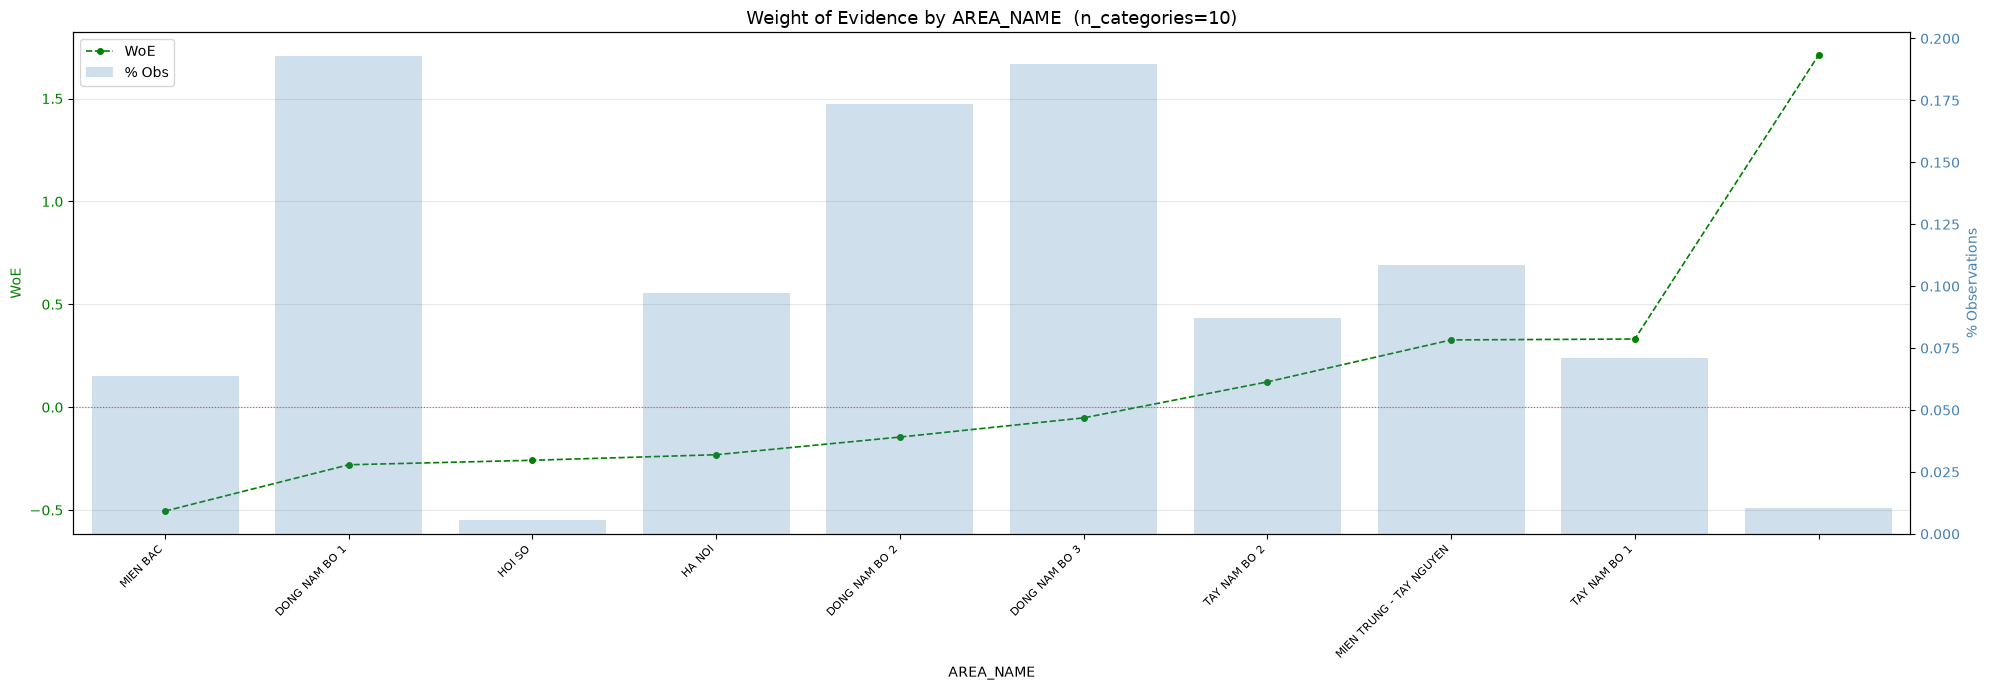

In [7]:
fig2 = woe.plot_woe_missing(df_woe_cont)

## Bảng kết quả của 3 trường hợp 
Bảng chứa MISSING, không chứa MISSING, và MISSING riêng

In [8]:
# Build 3 cases: FULL, MISSING_VS_REST, NO_MISSING
cases = woe.build_three_cases(df_woe_cont, missing_label="MISSING")

print("Case A - Full IV:", cases["full"])
type(cases["full"])


[build_three_cases] Warning: no bin 'MISSING' found.
Case A - Full IV:                  AREA_NAME  n_obs  prop_card  prop_n_obs  n_card  n_noncard  \
0                 MIEN BAC   3920   0.002296    0.063920     9.0     3911.0   
1            DONG NAM BO 1  11826   0.002875    0.192835    34.0    11792.0   
2                   HOI SO    342   0.002924    0.005577     1.0      341.0   
3                   HA NOI   5964   0.003018    0.097249    18.0     5946.0   
4            DONG NAM BO 2  10645   0.003288    0.173578    35.0    10610.0   
5            DONG NAM BO 3  11640   0.003608    0.189802    42.0    11598.0   
6             TAY NAM BO 2   5356   0.004294    0.087335    23.0     5333.0   
7  MIEN TRUNG - TAY NGUYEN   6652   0.005262    0.108468    35.0     6617.0   
8             TAY NAM BO 1   4353   0.005284    0.070980    23.0     4330.0   
9                             629   0.020668    0.010256    13.0      616.0   

   n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_non

pandas.DataFrame

In [9]:
print("Case B - Missing vs Rest IV:", cases["missing_vs_rest"])

Case B - Missing vs Rest IV: Empty DataFrame
Columns: []
Index: []


In [10]:
print("Case C - No Missing IV:", cases["no_missing"])

Case C - No Missing IV:                  AREA_NAME  n_obs  prop_card  prop_n_obs  n_card  n_noncard  \
0                 MIEN BAC   3920   0.002296    0.063920     9.0     3911.0   
1            DONG NAM BO 1  11826   0.002875    0.192835    34.0    11792.0   
2                   HOI SO    342   0.002924    0.005577     1.0      341.0   
3                   HA NOI   5964   0.003018    0.097249    18.0     5946.0   
4            DONG NAM BO 2  10645   0.003288    0.173578    35.0    10610.0   
5            DONG NAM BO 3  11640   0.003608    0.189802    42.0    11598.0   
6             TAY NAM BO 2   5356   0.004294    0.087335    23.0     5333.0   
7  MIEN TRUNG - TAY NGUYEN   6652   0.005262    0.108468    35.0     6617.0   
8             TAY NAM BO 1   4353   0.005284    0.070980    23.0     4330.0   
9                             629   0.020668    0.010256    13.0      616.0   

   n_card_smooth  n_noncard_smooth  prop_n_card  prop_n_noncard       WoE  \
0          9.005          391

## Lưu kết quả và tổng hợp qua file CSV, HTML

In [11]:
# Create feature output folder
import os
output_dir = f"output/{FEATURE_NAME}"
os.makedirs(output_dir, exist_ok=True)

# CSV only
woe.save_iv_csv(cases, f"{output_dir}/iv_cases.csv")

# HTML with plot
woe.save_iv_html(
    iv_dict=cases,
    plots={"WoE_Chart": fig2},
    output_path=f"{output_dir}/iv_cases.html",
    title=f"IV Summary - {FEATURE_NAME}",
)

'output/AREA_NAME/iv_cases.html'